<a href="https://colab.research.google.com/github/AlexBronte/mentor/blob/master/%D0%9C%D0%B5%D1%82%D1%80%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_%22hw_metric_models_ipynb%22%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Метрические модели (kNN)


В этом задании мы поработаем с алгоритмом **k-ближайших соседей (kNN)** и разными метриками расстояния.

Напоминание:
- kNN ищет ближайших соседей объекта по выбранной метрике.
- Класс нового объекта определяется большинством среди соседей.

Метрика расстояния сильно влияет на работу модели:
- **Евклидово расстояние** — учитывает величины признаков.
- **Манхэттенское расстояние** — сумма модулей разниц.
- **Мера Жаккара** — для множеств / бинарных признаков.
- **Косинусное расстояние** — для текстов/векторов, где важен угол, а не длина.


## 1. Загрузка данных

Будем рассматривать эту модель на примере датасета с ирисами Фишера

In [56]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Загружаем датасет iris
iris = load_iris()
# Возьмём 2 признака: длина и ширина лепестка
X, y = iris.data[:, (2, 3)], iris.target
X_2d = X.copy()

print("Размерность X:", X.shape)
print("Классы:", iris.target_names)


Размерность X: (150, 2)
Классы: ['setosa' 'versicolor' 'virginica']


## 2. Первая модель kNN (евклидово расстояние)

In [ ]:

# Разделим данные на train/test в соотношении 0.8: 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2) # <YOUR CODE HERE>

# Масштабируем данные
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train) # <YOUR CODE HERE>
X_test_scaled =scaler.transform(X_test) # <YOUR CODE HERE>

# Обучим kNN с евклидовой метрикой и количеством соседей = 5 (параметры n_neighbors и metric)
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean').fit(X_train_scaled,y_train) # <YOUR CODE HERE>


# Сделаем предсказания на тестовом множестве
y_pred =knn.predict(X_test_scaled) # <YOUR CODE HERE>
print("Accuracy (евклидово расстояние):", accuracy_score(y_test, y_pred))


Accuracy (евклидово расстояние): 1.0


## 3. Сравнение разных метрик

Обучим модель с использованием различных метрик расстояния: "euclidean", "manhattan", "cosine" и сравним получаемые значения accuracy_score

In [ ]:
metrics = ['euclidean', 'manhattan', 'cosine']
metric_scores = []
for metric in metrics:
  knn =KNeighborsClassifier(n_neighbors=5, metric=metric).fit(X_train_scaled,y_train)
  y_pred = knn.predict(X_test_scaled)
  metric_scores.append(y_pred)
    # <YOUR CODE HERE>
  print(f'Метрика {metric},точность={accuracy_score(y_test,y_pred):.4f}')

Метрика euclidean,точность=1.0000
Метрика manhattan,точность=1.0000
Метрика cosine,точность=0.9000


## 4. Визуализация границ для kNN

Построим границы классов для kNN для различных метрик

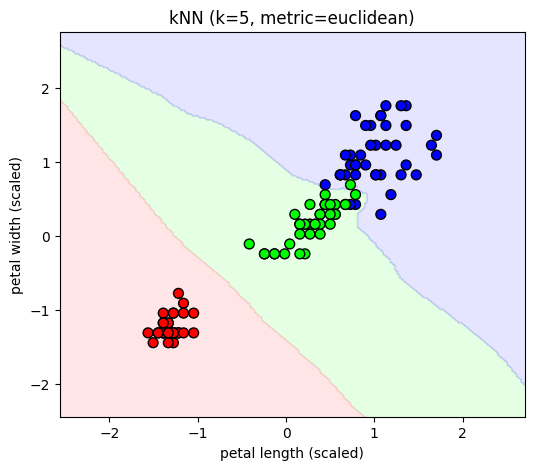

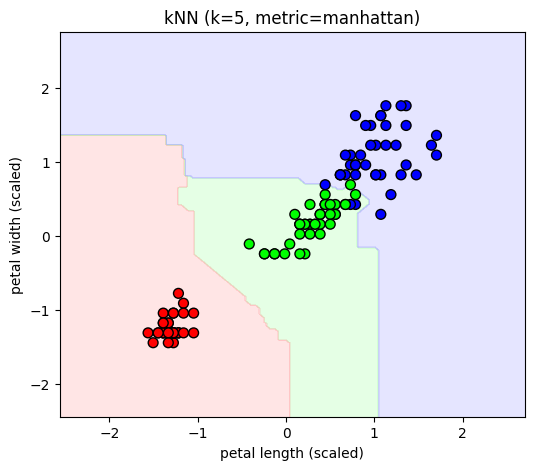

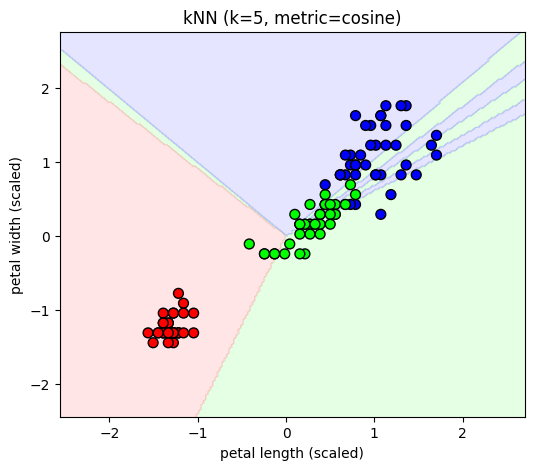

In [ ]:
from matplotlib.colors import ListedColormap

# Берём только 2 признака (лепестки)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2d, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

def plot_knn_boundaries(metric="euclidean", k=5):
    knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
    knn.fit(X_train2_scaled, y_train2)

    # Сетка для отрисовки
    x_min, x_max = X_train2_scaled[:, 0].min() - 1, X_train2_scaled[:, 0].max() + 1
    y_min, y_max = X_train2_scaled[:, 1].min() - 1, X_train2_scaled[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    plt.scatter(X_train2_scaled[:, 0], X_train2_scaled[:, 1], c=y_train2, cmap=cmap_bold, edgecolor="k", s=50)
    plt.title(f"kNN (k={k}, metric={metric})")
    plt.xlabel("petal length (scaled)")
    plt.ylabel("petal width (scaled)")
    plt.show()

# Пример: визуализация для разных метрик
for m in ["euclidean", "manhattan", "cosine"]:
    plot_knn_boundaries(metric=m, k=5)



## 5. Подбор гиперпараметров

Попробуем подобрать с помощью алгоритма GridSearchCV оптимальные значения количества соседей и метрику.

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_neighbors': [3,5,7,10],
    'metric': ['euclidean','manhattan','cosine']
}
grid = GridSearchCV(
    estimator=knn,
    param_grid=params,
    scoring='accuracy'
)

grid.fit(X_train_scaled,y_train)
print(f'Лучшие параметры:{grid.best_params_},лучшая метрика:{grid.best_score_} ') # <YOUR CODE HERE>

Лучшие параметры:{'metric': 'manhattan', 'n_neighbors': 5},лучшая метрика:0.9583333333333334 



## 6. Классификация текстов с kNN

- Сравним kNN с метрикой Жаккара и косинусным расстоянием на текстах.  
  Для этого можно взять небольшой список предложений и преобразовать их в мешок слов (`CountVectorizer`).

`CountVectorizer` работает следующим образом:
1. Проходит по всем текстам набора данных и составляет словарь, размер которого равен количеству уникальных токенов во всём корпусе текстов
2. Каждому токену присваивается индекс свой уникальный индекс i
3. Текст переводится в вектор размером длина словаря, в котором на i-ом месте записано число - частота встречаемости данного токена в данном тексте

Мы будем использовать корпус **20 newsgroups** из sklearn.  
Нужно векторизовать тексты с помощью `CountVectorizer` и обучить `KNeighborsClassifier`.  

`CountVectorizer` преобразует тексты в вектора следующим образом. Каждый текст превращается в вектор, размерность которого равна количеству слов во всём корпусе текстов. Каждому слову соответствует определённый индекс в этом векторе. Значение элемента равно количеству раз, которое слово встретилось в данном тексте. Если какого-то слова нет в тексте, то соответствующий элемент будет равен нулю.  

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


# Загружаем небольшой корпус (только 3 категории)
categories = ['sci.space', 'rec.sport.hockey', 'comp.graphics']
newsgroups = fetch_20newsgroups(subset='train', categories=categories)

X = newsgroups.data
y = newsgroups.target

# Разделим на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Посмотрим на один пример
print(X_train[22])
print('~'*70)
print('label:', y_train[22])

From: seale@possum.den.mmc.com (Eric H Seale)
Subject: Re: Comet in Temporary Orbit Around Jupiter?
Nntp-Posting-Host: pogo.den.mmc.com
Organization: Martin Marietta Astronautics, Denver
Lines: 8

baalke@kelvin.jpl.nasa.gov (Ron Baalke) writes:
>According the IAU Circular #5744, Comet Shoemaker-Levy 1993e, may be
>temporarily in orbit around Jupiter.  The comet had apparently made a
>close flyby of Jupiter sometime in 1992 resulting in the breakup of the
>comet.

Ooooh -- who would have thought that Galileo would get the chance to
check out a comet TOO?!?

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
label: 2


Как видно, в текстах содержится много мусора: междометия, емейлы, названия сайтов. Проблема в том, что если мы применим `CountVectorizer` к необработанным текстам, размер словаря сильно увеличится, при этом многие из этих токенов не несут никакого смысла. Также мы не хотим, чтобы одно и то же слово, записанное в разных регистрах, воспринималось моделью как разные токены.

Поэтому перед применением алгоритма kNN следует выполнить предобработку текста. К счастью, алгоритм `CountVectorizer` может сам предобработать тексты. Для этого есть специальные параметры:
- **stop_words='english'**  
  Убирает стоп-слова (частые и малоинформативные слова вроде *"the"*, *"is"*, *"and"*).  
  Это помогает модели не тратить внимание на "шум".

- **lowercase=True**  
  Приводит все слова к нижнему регистру.  
  Например, "Dog" и "dog" будут считаться одним и тем же словом.

- **min_df=n**  
  Отбрасывает слова, которые встречаются **меньше чем в n документах**.  
  Такие редкие слова часто не помогают в классификации и могут мешать.

- **max_df=0.9**  
  Отбрасывает слова, которые встречаются **более чем в 90% документов**.  
  Очень частые слова не несут полезной информации (например, "said", "one").

- **token_pattern=r'[a-zA-Z]{2,}'**  
  Регулярное выражение для выделения слов (токенов).  
  Здесь мы берём только последовательности букв латинского алфавита длиной **не меньше 2 символов**.  
  → Однобуквенные "слова" вроде "a" или "I" будут отфильтрованы

Реализуем векторизацию текстов с использованием данных параметров

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(
    stop_words = 'english',
    lowercase = True,
    min_df = 2,
    max_df = 0.9,
    token_pattern=r'[a-zA-Z]{2,}'
) # <YOUR CODE HERE>
X_train_vec = vectorizer.fit_transform(X_train) # <YOUR CODE HERE>
X_test_vec = vectorizer.transform(X_test)# <YOUR CODE HERE>

Для простоты бинаризуем наши вектора: на i-ой позиции будет стоять 1, если слово присутствует в нашем тексте (неважно, какое количество раз), иначе - 0

In [ ]:
X_train_bin = (X_train_vec > 0).astype(int)
X_test_bin = (X_test_vec > 0).astype(int)

## 7. Реализация метрики Жаккара

В sklearn нет встроенной поддержки меры Жаккара в качестве метрики. Однако можно написать свою кастомную метрику вычисления расстояния и передать её как функцию в качестве значения параметра `metric`.

Реализуем вычисление меры Жаккара

In [ ]:
from scipy.sparse import csr_matrix
import numpy as np

def jaccard_similarity(vec1, vec2):
    # Optimized for scipy sparse matrices
    # Ensure we are working with rows
    v1 = vec1.tocsr()
    v2 = vec2.tocsr()

    # Intersection: multiply elements and count non-zeros
    intersection = v1.multiply(v2).nnz

    # Union: Sum of non-zeros in each minus intersection
    union = v1.nnz + v2.nnz - intersection

    if union == 0:
        return 0.0
    return intersection / union

In [ ]:
# Мера Жаккара
def jaccard_distance(x, y):
    return 1 - jaccard_similarity(x, y)

## 8. Сравнение метрик jaccard distance и cosine similarity

Обучим алгоритм kNN на текстах с использованием метрик cosine и jaccard_distance и сравним результаты при помощи набора метрик  `classification_report` из sklearn

In [ ]:
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn.fit(X_train_bin,y_train)
y_pred = knn.predict(X_test_vec)
print(classification_report(y_test, y_pred,target_names=categories))

                  precision    recall  f1-score   support

       sci.space       0.92      0.96      0.94       128
rec.sport.hockey       0.98      0.96      0.97       114
   comp.graphics       0.97      0.95      0.96       114

        accuracy                           0.96       356
       macro avg       0.96      0.95      0.96       356
    weighted avg       0.96      0.96      0.96       356



In [55]:
# 1. Initialize the classifier with the custom function
knn_jaccard = KNeighborsClassifier(n_neighbors=5, metric=jaccard_distance)

# 2. Fit the model on binarized data
knn_jaccard.fit(X_train_bin, y_train)

# 3. Predict
y_pred_jaccard = knn_jaccard.predict(X_test_bin)

# 4. Show results
print("Jaccard Distance Classification Report:")
print(classification_report(y_test, y_pred_jaccard, target_names=categories))

Jaccard Distance Classification Report:
                  precision    recall  f1-score   support

       sci.space       0.88      0.95      0.92       128
rec.sport.hockey       0.98      0.94      0.96       114
   comp.graphics       0.95      0.91      0.93       114

        accuracy                           0.94       356
       macro avg       0.94      0.93      0.94       356
    weighted avg       0.94      0.94      0.94       356

